# অধ্যায় ৩: অতত্ত্বাবধানে শিক্ষণ (Unsupervised Learning)
## পাঠ ৩.১: প্রিপ্রসেসিং ও স্কেলিং
### (Preprocessing & Scaling)

![ML for Kids](https://img.shields.io/badge/ML-for%20Kids-brightgreen)

স্বাগতম! আজ আমরা শিখবো কিভাবে আমাদের ডেটাকে মেশিন লার্নিং অ্যালগরিদমের জন্য তৈরি করা হয়।

## 🌟 গল্প: "ভিন্ন এককে ভিন্ন মান"

একদিন তিন বন্ধু — রহিম, করিম এবং ফাতেমা — তাদের বাগানের ফল নিয়ে কথা বলছিল।

রহিম বলল, "আমার গাছ থেকে ৫০০০ গ্রাম আম পেরেছি!"
করিম বলল, "আমার গাছ থেকে ৫ কেজি আম পেরেছি!"
ফাতেমা বলল, "আমার গাছ থেকে ১০ পাউন্ড আম পেরেছি!"

তারা তিনজনই কি একই পরিমাণ আম পেরেছে? হ্যাঁ! কিন্তু সংখ্যাগুলো ভিন্ন দেখাচ্ছে কারণ তারা ভিন্ন ভিন্ন একক (unit) ব্যবহার করেছে।

মেশিন লার্নিংয়েও একই সমস্যা হয়। আমাদের ডেটাতে বিভিন্ন ফিচারের (feature) মান বিভিন্ন রেঞ্জে থাকে। যেমন:
- কোনো ফিচারের মান ০ থেকে ১০০০ হতে পারে (যেমন বয়স)
- কোনো ফিচারের মান ০ থেকে ১ হতে পারে (যেমন জিপিএ)
- কোনো ফিচারের মান ১০০০০ থেকে ১০০০০০ হতে পারে (যেমন বেতন)

মেশিন লার্নিং অ্যালগরিদম এই ভিন্ন রেঞ্জের মানগুলো নিয়ে বিভ্রান্ত হয়ে যায়। বড় মানের ফিচারগুলো ছোট মানের ফিচারগুলোর উপর প্রভাব ফেলে। তাই আমাদের ডেটাকে একই রকম স্কেলে নিয়ে আসতে হয়। একেই বলে **স্কেলিং (Scaling)** বা **প্রিপ্রসেসিং (Preprocessing)**।

ভাবো তো, তুমি যদি একজন শিক্ষক হও এবং তুমি দুইজন ছাত্রের নম্বর তুলনা করতে চাও — একজন পেয়েছে গণিতে ৯০ (১০০-এর মধ্যে) এবং অন্যজন পেয়েছে বিজ্ঞানে ৪৫ (৫০-এর মধ্যে)। সরাসরি ৯০ আর ৪৫ তুলনা করা কি ঠিক হবে? না, কারণ এরা ভিন্ন পূর্ণমানের। একে প্রথমে একই স্কেলে আনতে হবে।

মেশিন লার্নিংয়ে ঠিক এই কাজটাই আমরা করি — সব ফিচারকে একই স্কেলে নিয়ে আসি। চলো দেখি কিভাবে!

## 🎯 প্রিপ্রসেসিং কেন প্রয়োজন?

প্রিপ্রসেসিং বা ডেটা প্রস্তুত করার মূল কারণগুলো:

1. **ভিন্ন স্কেলের সমস্যা**: বিভিন্ন ফিচার ভিন্ন রেঞ্জে থাকলে, বড় রেঞ্জের ফিচারগুলো মডেলের ওপর বেশি প্রভাব ফেলে
2. **অ্যালগরিদমের প্রয়োজন**: কিছু অ্যালগরিদম (যেমন KNN, SVM, PCA) স্কেলিং ছাড়া ভালো কাজ করে না
3. **গণনার গতি**: স্কেল করা ডেটা নিয়ে কাজ করা দ্রুত হয়
4. **ভালো নির্ভুলতা**: স্কেলিং অনেক সময় মডেলের নির্ভুলতা বাড়ায়

চলো, আমরা প্রথমে Python-এ প্রয়োজনীয় লাইব্রেরি ইম্পোর্ট করি।

In [1]:
# প্রয়োজনীয় লাইব্রেরি ইম্পোর্ট করি
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.pipeline import Pipeline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ লাইব্রেরি লোড হয়েছে!")

✅ লাইব্রেরি লোড হয়েছে!


## 📊 আমাদের ডেটা

আমরা Iris (আইরিস) ডেটাসেট ব্যবহার করব। এটি বিখ্যাত একটি ডেটাসেট যা scikit-learn-এ আছে। এতে ৩ রকমের ফুলের পাপড়ি ও সিপালের পরিমাপ আছে।

In [2]:
# Iris ডেটাসেট লোড করি
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({0: target_names[0], 1: target_names[1], 2: target_names[2]})
print("📝 ডেটার আকৃতি:", X.shape)
print("\n📋 ফিচারগুলোর নাম:", feature_names)
print("\n🏷️ টার্গেট ক্লাস:", target_names)
print("\n📊 প্রথম 5 সারি:")
df.head()

📝 ডেটার আকৃতি: (150, 4)

📋 ফিচারগুলোর নাম: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

🏷️ টার্গেট ক্লাস: ['setosa' 'versicolor' 'virginica']

📊 প্রথম 5 সারি:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### ফিচারগুলোর স্কেল দেখা যাক

লক্ষ্য করো, প্রতিটি ফিচারের মানের রেঞ্জ আলাদা:
- sepal length (cm): ৪.৩ থেকে ৭.৯
- sepal width (cm): ২.০ থেকে ৪.৪
- petal length (cm): ১.০ থেকে ৬.৯
- petal width (cm): ০.১ থেকে ২.৫

এই ভিন্ন স্কেলের কারণে KNN-এর মতো অ্যালগরিদম বিভ্রান্ত হতে পারে। চলো দেখি কিভাবে।

C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3095411919.py:11: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[feature_names].hist(ax=axes[1], bins=15, layout=(2, 2))


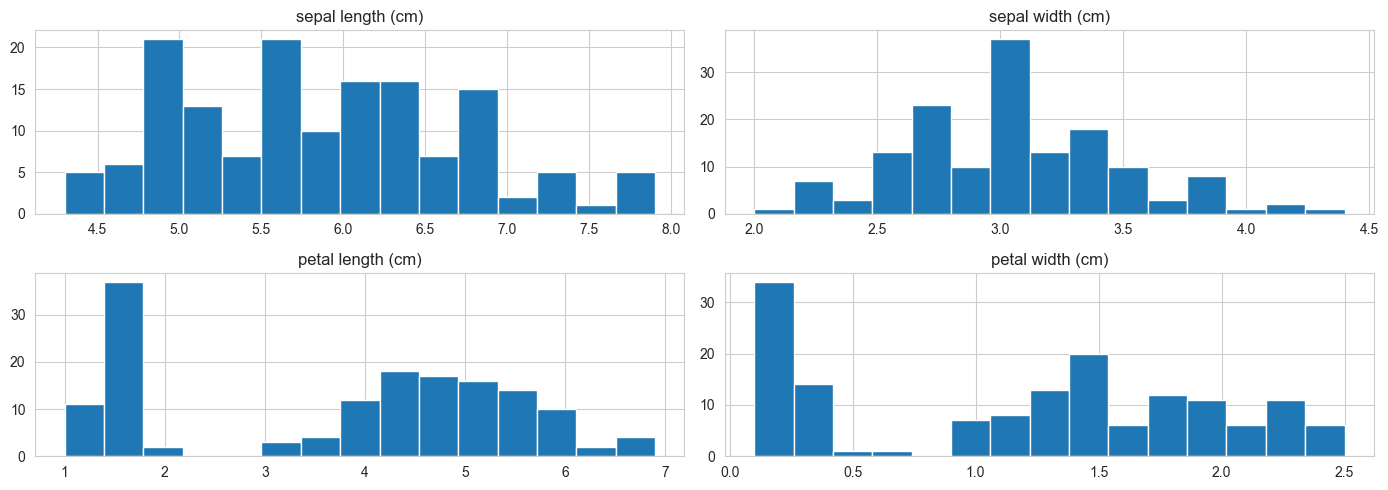

👆 দেখো, প্রতিটি ফিচারের মানের রেঞ্জ আলাদা আলাদা!


In [3]:
# ফিচারগুলোর রেঞ্জ可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# বক্স প্লট
df[feature_names].boxplot(ax=axes[0])
axes[0].set_title('আসল ডেটার বক্স প্লট', fontsize=14, fontweight='bold')
axes[0].set_ylabel('মান (cm)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# হিস্টোগ্রাম
df[feature_names].hist(ax=axes[1], bins=15, layout=(2, 2))
axes[1].set_title('আসল ডেটার হিস্টোগ্রাম', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()
print("👆 দেখো, প্রতিটি ফিচারের মানের রেঞ্জ আলাদা আলাদা!")

## 🧪 বিভিন্ন ধরণের স্কেলার

আমরা ৪ টি প্রধান স্কেলিং পদ্ধতি শিখব:

### ১. StandardScaler (স্ট্যান্ডার্ড স্কেলার) ⭐
এটি সবচেয়ে বেশি ব্যবহৃত স্কেলার। এটি প্রতিটি ফিচার থেকে তার গড় (mean) বাদ দেয় এবং স্ট্যান্ডার্ড ডেভিয়েশন (standard deviation) দিয়ে ভাগ করে। ফলে সব ফিচারের গড় হয় ০ এবং স্ট্যান্ডার্ড ডেভিয়েশন হয় ১।

গণিতের ভাষায়: z = (x - μ) / σ
- μ = গড়, σ = স্ট্যান্ডার্ড ডেভিয়েশন

**কখন ব্যবহার করব?** যখন ডেটা প্রায় নরমাল ডিস্ট্রিবিউশন অনুসরণ করে এবং আমরা আউটলায়ার নিয়ে চিন্তিত না।

### ২. MinMaxScaler (মিন-ম্যাক্স স্কেলার) 📏
এটি ডেটাকে একটি নির্দিষ্ট রেঞ্জে (সাধারণত ০ থেকে ১) নিয়ে আসে। প্রতিটি ফিচার থেকে তার মিনিমাম মান বাদ দিয়ে রেঞ্জ (ম্যাক্স - মিন) দিয়ে ভাগ করে।

গণিত: X_scaled = (X - X_min) / (X_max - X_min)

**কখন ব্যবহার করব?** যখন আমরা জানি ডেটা একটি নির্দিষ্ট রেঞ্জে থাকবে (যেমন পিক্সেল ভ্যালু ০-২৫৫)।

### ৩. RobustScaler (রোবাস্ট স্কেলার) 🛡️
এটি StandardScaler-এর মতোই, কিন্তু মিডিয়ান এবং IQR (Interquartile Range) ব্যবহার করে। এটি আউটলায়ারের প্রতি কম সংবেদনশীল।

গণিত: X_scaled = (X - মিডিয়ান) / IQR

**কখন ব্যবহার করব?** যখন ডেটাতে অনেক আউটলায়ার (outlier) থাকে।

### ৪. Normalizer (নরমালাইজার) 🔄
এটি প্রতিটি ডেটা পয়েন্ট (সারি) কে তার নিজস্ব ইউক্লিডিয়ান নর্ম (Euclidean norm) দিয়ে ভাগ করে। অর্থাৎ প্রতিটি সারির মানগুলোর বর্গের যোগফল = ১ হয়।

**কখন ব্যবহার করব?** যখন আমরা ডেটার দিক (direction) নিয়ে চিন্তিত, পরিমাণ (magnitude) নিয়ে না (যেমন টেক্সট ডেটার সাথে কাজ করার সময়)।

In [4]:
# সব ধরণের স্কেলার তৈরি করি
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
normalizer = Normalizer()

# স্কেলিং করার আগে ডেটা
X_original = X.copy()

# প্রতিটি স্কেলার দিয়ে ডেটা স্কেল করি
X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)
X_robust = robust_scaler.fit_transform(X)
X_normalized = normalizer.fit_transform(X)

# ফলাফল দেখি
scaling_results = pd.DataFrame({
    'আসল': X[:, 0],
    'StandardScaler': X_standard[:, 0],
    'MinMaxScaler': X_minmax[:, 0],
    'RobustScaler': X_robust[:, 0],
    'Normalizer': X_normalized[:, 0]
})
print("📊 প্রথম ফিচারের (sepal length) উপর বিভিন্ন স্কেলারের প্রভাব:")
print("="*70)
scaling_results.head(10)

📊 প্রথম ফিচারের (sepal length) উপর বিভিন্ন স্কেলারের প্রভাব:


,আসল,StandardScaler,MinMaxScaler,RobustScaler,Normalizer
0,5.1,-0.900681,0.222222,-0.538462,0.803773
1,4.9,-1.143017,0.166667,-0.692308,0.828133
2,4.7,-1.385353,0.111111,-0.846154,0.805333
3,4.6,-1.506521,0.083333,-0.923077,0.800030
4,5.0,-1.021849,0.194444,-0.615385,0.790965
5,5.4,-0.537178,0.305556,-0.307692,0.784175
6,4.6,-1.506521,0.083333,-0.923077,0.780109
7,5.0,-1.021849,0.194444,-0.615385,0.802185
8,4.4,-1.748856,0.027778,-1.076923,0.806424
9,4.9,-1.143017,0.166667,-0.692308,0.818031


### দৃশ্যত তুলনা করা যাক

চলো দেখি বিভিন্ন স্কেলার কিভাবে ডেটাকে পরিবর্তন করে। আমরা প্রথম দুটি ফিচার ব্যবহার করে একটি ২D প্লট তৈরি করব।

C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\2835407252.py:24: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ip

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

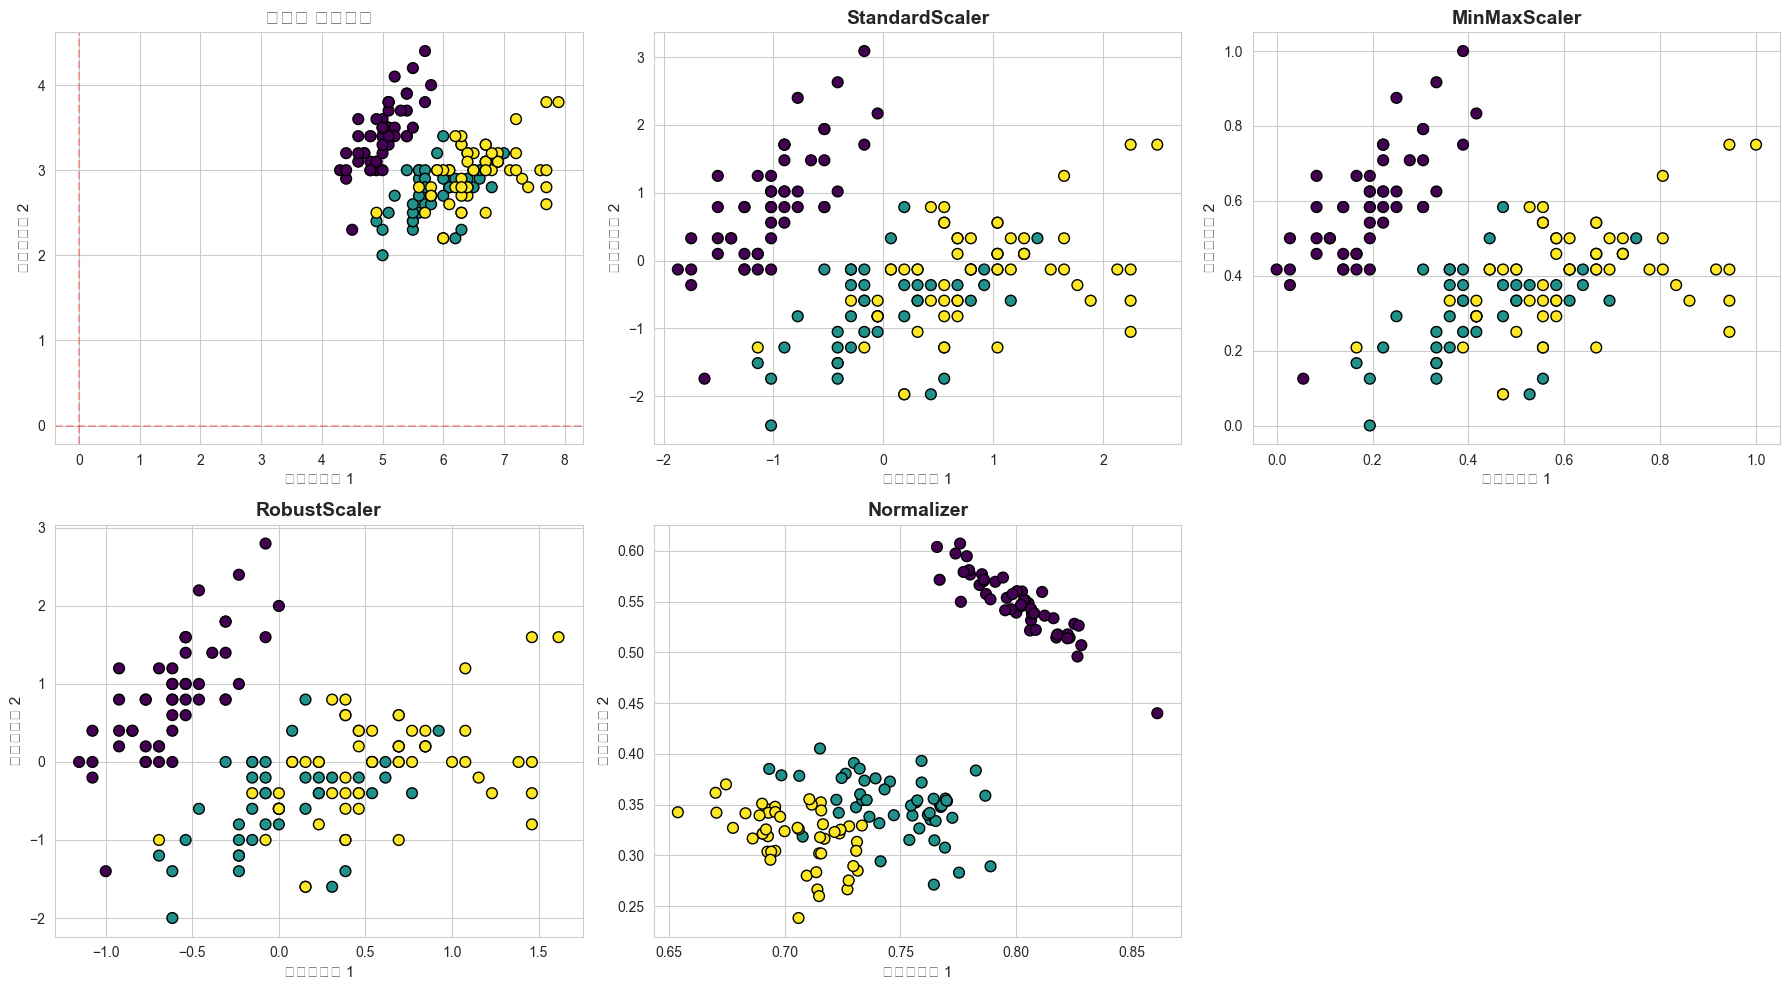

👆 লক্ষ্য করো প্রতিটি স্কেলার ডেটাকে ভিন্নভাবে রূপান্তরিত করেছে!


In [5]:
# বিভিন্ন স্কেলারের ফলাফল দৃশ্যত দেখা
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (X_original[:, :2], 'আসল ডেটা', 0, 0),
    (X_standard[:, :2], 'StandardScaler', 0, 1),
    (X_minmax[:, :2], 'MinMaxScaler', 0, 2),
    (X_robust[:, :2], 'RobustScaler', 1, 0),
    (X_normalized[:, :2], 'Normalizer', 1, 1),
]

for data, title, row, col in datasets:
    axes[row, col].scatter(data[:, 0], data[:, 1], c=y, cmap='viridis', edgecolors='k', s=60)
    axes[row, col].set_title(f'{title}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('ফিচার 1', fontsize=11)
    axes[row, col].set_ylabel('ফিচার 2', fontsize=11)
    if title == 'আসল ডেটা':
        axes[row, col].axhline(y=0, color='red', linestyle='--', alpha=0.3)
        axes[row, col].axvline(x=0, color='red', linestyle='--', alpha=0.3)

# শেষ প্লটটা খালি রাখি
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
print("👆 লক্ষ্য করো প্রতিটি স্কেলার ডেটাকে ভিন্নভাবে রূপান্তরিত করেছে!")

## 🤖 KNN-এর উপর স্কেলিং-এর প্রভাব

এবার আমরা বাস্তব উদাহরণ দিয়ে দেখবো কেন স্কেলিং গুরুত্বপূর্ণ। K-Nearest Neighbors (KNN) অ্যালগরিদম ডেটা পয়েন্টের মধ্যে দূরত্ব (distance) ব্যবহার করে। যদি ফিচারগুলোর স্কেল আলাদা হয়, তাহলে বড় স্কেলের ফিচারগুলো দূরত্বের ওপর বেশি প্রভাব ফেলে।

ভাবো তো, তুমি দুই বন্ধুর বাড়ির দূরত্ব মাপছ। একজন বন্ধুর বাড়ি ২ কিমি দূরে আর আরেকজনের ৫০০০ মিটার দূরে। ২ আর ৫০০০ — এই সংখ্যাগুলো দেখে তুমি ভাববে দ্বিতীয় বন্ধু অনেক দূরে। কিন্তু আসলে ৫০০০ মিটার = ৫ কিমি! তাই ইউনিট কনভার্ট না করে তুলনা করা বিভ্রান্তিকর।

KNN-এর ক্ষেত্রেও একই ঘটনা ঘটে। স্কেলিং না করলে বড় মানের ফিচার ছোট মানের ফিচারকে "ঢেকে" ফেলে।

চলো, আমরা Iris ডেটাতে KNN চালাই — প্রথমে স্কেলিং ছাড়া, তারপর স্কেলিং সহ — এবং নির্ভুলতা (accuracy) তুলনা করি।

In [6]:
# ট্রেন-টেস্ট স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# স্কেলিং ছাড়া KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_no_scaling = knn.predict(X_test)
accuracy_no_scaling = knn.score(X_test, y_test)
print(f"📉 স্কেলিং ছাড়া KNN-এর নির্ভুলতা: {accuracy_no_scaling:.2%}")
print()

# StandardScaler দিয়ে KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = knn_scaled.score(X_test_scaled, y_test)
print(f"📈 StandardScaler-সহ KNN-এর নির্ভুলতা: {accuracy_scaled:.2%}")
print()
print(f"🎯 নির্ভুলতা পরিবর্তন: {accuracy_scaled - accuracy_no_scaling:+.2%}")

📉 স্কেলিং ছাড়া KNN-এর নির্ভুলতা: 100.00%

📈 StandardScaler-সহ KNN-এর নির্ভুলতা: 100.00%

🎯 নির্ভুলতা পরিবর্তন: +0.00%


### সব স্কেলারের সাথে KNN তুলনা

চলো, সব ধরণের স্কেলার ব্যবহার করে KNN-এর নির্ভুলতা দেখি এবং তুলনা করি।

In [7]:
# সব স্কেলারের সাথে KNN-এর নির্ভুলতা তুলনা
scalers = {
    'কোন স্কেলিং নেই': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'Normalizer': Normalizer()
}

results = {}

for name, scaler in scalers.items():
    if scaler is None:
        X_train_tr = X_train.copy()
        X_test_tr = X_test.copy()
    else:
        X_train_tr = scaler.fit_transform(X_train)
        X_test_tr = scaler.transform(X_test)
    
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train_tr, y_train)
    acc = knn.score(X_test_tr, y_test)
    results[name] = acc

# ফলাফল দেখি
results_df = pd.DataFrame(list(results.items()), columns=['স্কেলার', 'নির্ভুলতা'])
results_df['নির্ভুলতা'] = results_df['নির্ভুলতা'].map('{:.2%}'.format)
print("🏆 বিভিন্ন স্কেলারের সাথে KNN-এর নির্ভুলতা:")
print("="*45)
results_df

🏆 বিভিন্ন স্কেলারের সাথে KNN-এর নির্ভুলতা:


,স্কেলার,নির্ভুলতা
0,কোন স্কেলিং নেই,100.00%
1,StandardScaler,100.00%
2,MinMaxScaler,100.00%
3,RobustScaler,95.56%
4,Normalizer,97.78%


### দৃশ্যত তুলনা: KNN ডিসিশন বাউন্ডারি

চলো আমরা দেখি কিভাবে স্কেলিং KNN-এর ডিসিশন বাউন্ডারি (সীমারেখা) পরিবর্তন করে। আমরা প্রথম দুটি ফিচার নিয়ে কাজ করব।

C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ipykernel_7800\3019221122.py:42: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hp\AppData\Local\Temp\ip

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2458 (\N{BENGALI LETTER CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24

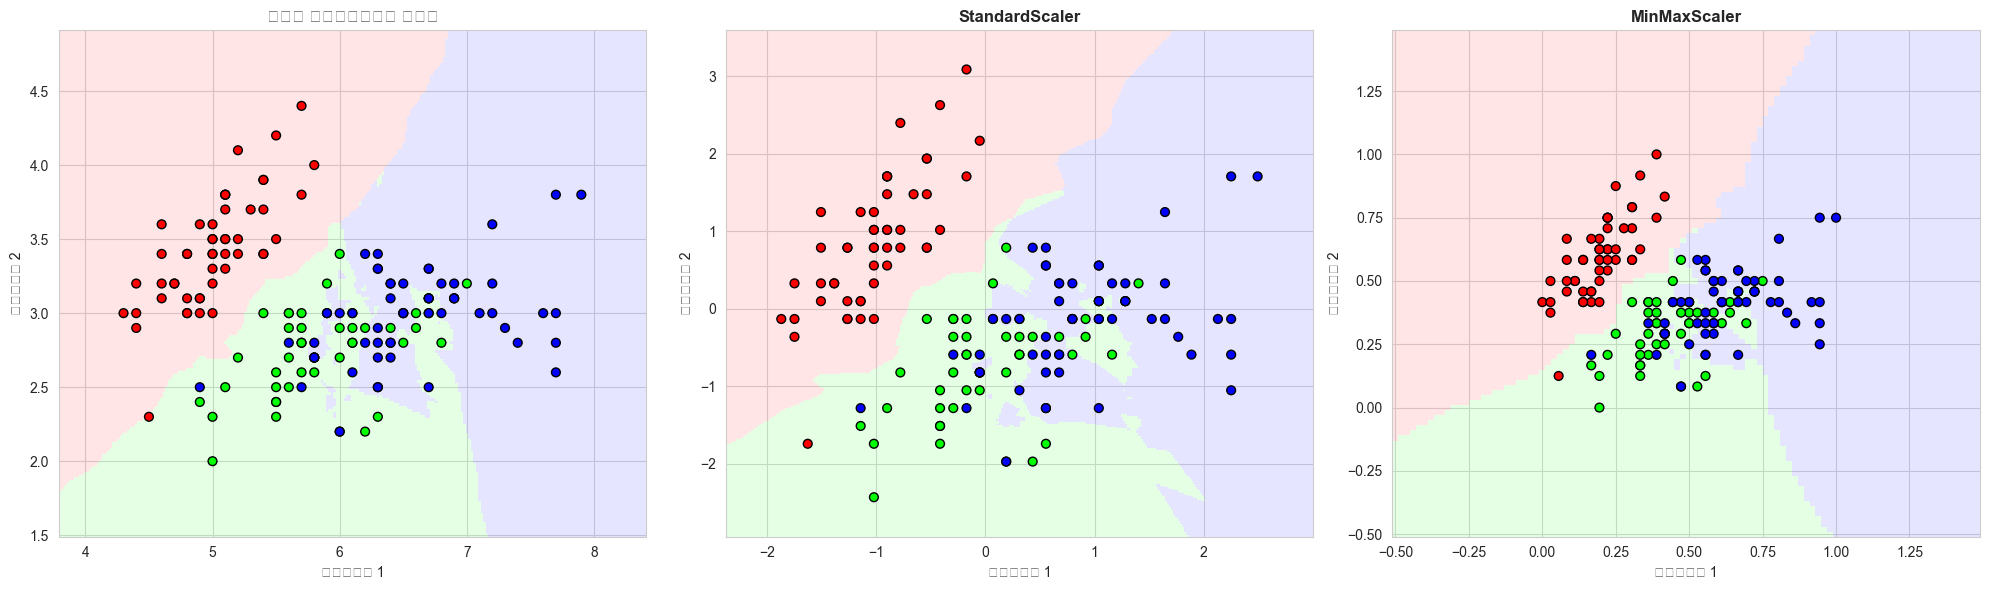

👆 দেখো, স্কেলিং করার পর ডিসিশন বাউন্ডারি কেমন পরিবর্তিত হয়েছে!


In [8]:
# KNN ডিসিশন বাউন্ডারি দেখা
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X_data, y_data, scaler, title, ax):
    h = 0.02
    
    if scaler is not None:
        X_data_scaled = scaler.fit_transform(X_data)
    else:
        X_data_scaled = X_data.copy()
    
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_data_scaled, y_data)
    
    x_min, x_max = X_data_scaled[:, 0].min() - 0.5, X_data_scaled[:, 0].max() + 0.5
    y_min, y_max = X_data_scaled[:, 1].min() - 0.5, X_data_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])
    
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.3)
    scatter = ax.scatter(X_data_scaled[:, 0], X_data_scaled[:, 1], c=y_data, cmap=cmap_bold, edgecolor='k', s=40)
    ax.set_xlabel('ফিচার 1', fontsize=10)
    ax.set_ylabel('ফিচার 2', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# প্রথম 2টি ফিচার নিই
X_2d = X[:, :2]
y_2d = y

plot_decision_boundary(X_2d, y_2d, None, 'কোন স্কেলিং নেই', axes[0])
plot_decision_boundary(X_2d, y_2d, StandardScaler(), 'StandardScaler', axes[1])
plot_decision_boundary(X_2d, y_2d, MinMaxScaler(), 'MinMaxScaler', axes[2])

plt.tight_layout()
plt.show()
print("👆 দেখো, স্কেলিং করার পর ডিসিশন বাউন্ডারি কেমন পরিবর্তিত হয়েছে!")

## 🎮 খেলা: নিজে করো!

এখন তুমি নিজে বিভিন্ন k-মান (n_neighbors) দিয়ে এবং বিভিন্ন স্কেলার দিয়ে KNN চালিয়ে দেখো কিভাবে নির্ভুলতা পরিবর্তিত হয়।

In [9]:
# 🎯 তুমি এখানে নিজে এক্সপেরিমেন্ট করতে পারো!
# বিভিন্ন k-মান এবং স্কেলার নিয়ে খেলো

my_k = 7  # এই মান পরিবর্তন করো (যেমন 1, 3, 5, 7, 11)
my_scaler = StandardScaler()  # এটি পরিবর্তন করো: MinMaxScaler(), RobustScaler(), Normalizer()

X_train_s = my_scaler.fit_transform(X_train)
X_test_s = my_scaler.transform(X_test)

my_knn = KNeighborsClassifier(n_neighbors=my_k)
my_knn.fit(X_train_s, y_train)
my_accuracy = my_knn.score(X_test_s, y_test)
print(f"🤖 k = {my_k} এবং {type(my_scaler).__name__} ব্যবহার করে")
print(f"🎯 নির্ভুলতা: {my_accuracy:.2%}")
print()
print("💡 উপরের কোড সেলে my_k এবং my_scaler পরিবর্তন করে দেখো কী হয়!")

🤖 k = 7 এবং StandardScaler ব্যবহার করে
🎯 নির্ভুলতা: 100.00%

💡 উপরের কোড সেলে my_k এবং my_scaler পরিবর্তন করে দেখো কী হয়!


## 📊 Pipeline ব্যবহার করে স্কেলিং

scikit-learn-এ Pipeline ব্যবহার করে আমরা স্কেলিং এবং মডেল একসাথে চেইন করতে পারি। এটি খুবই সুবিধাজনক।

In [10]:
# Pipeline ব্যবহার
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

pipeline.fit(X_train, y_train)
pipeline_accuracy = pipeline.score(X_test, y_test)
print(f"🔗 Pipeline-এর সাহায্যে KNN-এর নির্ভুলতা: {pipeline_accuracy:.2%}")
print()
print("✨ Pipeline একসাথে সব কাজ করে দেয় — স্কেলিং + মডেল ট্রেনিং!")

🔗 Pipeline-এর সাহায্যে KNN-এর নির্ভুলতা: 100.00%

✨ Pipeline একসাথে সব কাজ করে দেয় — স্কেলিং + মডেল ট্রেনিং!


## 🌟 মজার তথ্য!

🎯 **StandardScaler** ধরে নেয় ডেটা নরমাল ডিস্ট্রিবিউশন অনুসরণ করে (ঘণ্টার মতো আকৃতি)।

🎯 **MinMaxScaler** ০-১ রেঞ্জে নিয়ে আসে — এটা অনেকটা শতাংশের মতো। ০.৫ মানে ৫০%।

🎯 **RobustScaler** মিডিয়ান ব্যবহার করে — মিডিয়ান হলো মাঝের মান। যেমন ৫ বন্ধুর বয়স ৫, ৭, ৮, ১০, ৬০ হলে মিডিয়ান ৮ (মাঝের সংখ্যা), গড় প্রায় ১৮ হবে। ৬০ বছর বয়সী আউটলায়ারটি মিডিয়ানে তেমন প্রভাব ফেলে না।

🎯 **Normalizer** প্রতিটি সারিকে আলাদাভাবে দেখে — ভেক্টরের দৈর্ঘ্য ১ করে দেয়।

## 🧠 তুমি কি বুঝতে পেরেছ?

নিচের প্রশ্নগুলোর উত্তর নিজের কাছে দাও:

❓ **প্রশ্ন ১**: স্কেলিং কেন দরকার? তুমি কি তোমার নিজের ভাষায় ব্যাখ্যা করতে পারো?

❓ **প্রশ্ন ২**: StandardScaler এবং MinMaxScaler-এর মধ্যে পার্থক্য কী?

❓ **প্রশ্ন ৩**: কখন RobustScaler ব্যবহার করা উচিত?

❓ **প্রশ্ন ৪**: KNN অ্যালগরিদমে স্কেলিং কেন গুরুত্বপূর্ণ?

❓ **প্রশ্ন ৫**: Normalizer অন্যদের থেকে কিভাবে আলাদা?

---

**🧪 পরীক্ষা**: উপরের কোড সেলে গিয়ে k-এর মান বদলাও এবং প্রতিবার ফলাফল দেখো। k=১ হলে কি হয়? k=১৫ হলে কি হয়?

---

**📝 মনে রেখো**:
- সব মেশিন লার্নিং অ্যালগরিদমের স্কেলিং প্রয়োজন হয় না (যেমন Decision Trees, Random Forest)
- কিন্তু দূরত্ব-ভিত্তিক অ্যালগরিদমের (KNN, SVM, K-Means, PCA) জন্য স্কেলিং খুবই গুরুত্বপূর্ণ
- Pipeline ব্যবহার করলে স্কেলিং এবং মডেল ট্রেনিং একসাথে করা যায় — ভুল হওয়ার সম্ভাবনা কমে

---

**🎉 অভিনন্দন!** তুমি প্রিপ্রসেসিং ও স্কেলিং-এর মূল ধারণাগুলো শিখে ফেলেছো। এখন তুমি জানো কিভাবে ডেটাকে মেশিন লার্নিং অ্যালগরিদমের জন্য তৈরি করতে হয়।